# Figures 3-5: Gaussian SIGW spectra from the tabulated kernel

Reproduces `table_coverage.pdf` (Fig. 3), `OGW_flat.pdf` (Fig. 4) and
`OGW_lognormal.pdf`/`peak_ratio.pdf` (Fig. 5), reading the exported
`kernels_data/` table (`\overline{I^2}(t,s;k)`, Sec. II.D of the Draft) --
no mode-function solving happens in this notebook.

In [1]:
import sys, os, glob
sys.path.insert(0, os.path.abspath("../core"))
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid
import matplotlib.cm as cm

import plotstyle; plotstyle.use_latex()
plt.rcParams.update({
    "font.size": 16, "axes.labelsize": 19, "axes.titlesize": 17,
    "legend.fontsize": 13.5, "xtick.labelsize": 16, "ytick.labelsize": 16,
})

import kernel as K
import spectra as sp
import background_qcd as qcd

KDATA = os.path.abspath("../kernels_data")
DATA = os.path.abspath("../data")
FIGDIR = os.path.abspath("../../Draft/Figures")
ETA_F = 0.5
NHZ_TO_HZ = 1e-9

T_OBS_S = 16.0 * 365.25 * 24.0 * 3600.0
PTA_F_LO_HZ, PTA_F_HI_HZ = 1.0 / T_OBS_S, 20.0 / T_OBS_S
PTA_K_LO = float(sp.f_Hz_to_k(np.array([PTA_F_LO_HZ]))[0])
PTA_K_HI = float(sp.f_Hz_to_k(np.array([PTA_F_HI_HZ]))[0])


def add_pta_band(ax, kind="k"):
    lo, hi = (PTA_K_LO, PTA_K_HI) if kind == "k" else (PTA_F_LO_HZ, PTA_F_HI_HZ)
    ax.axvspan(lo, hi, color="0.85", zorder=0, lw=0)


def load_tables():
    files = sorted(glob.glob(os.path.join(KDATA, "kernel_f*.npz")),
                   key=lambda fn: float(np.load(fn)["f_nHz"]))
    tabs = [np.load(fn) for fn in files]
    f_nHz = np.array([float(t["f_nHz"]) for t in tabs])
    ks = np.array([float(t["k"]) for t in tabs])
    return tabs, f_nHz, ks


def Ph_from_table(tab, pz, k):
    t, s, I2 = tab["t"], tab["s"], tab["I2bar"]
    T, S = np.meshgrid(t, s, indexing="ij")
    W = K.weight(T, S) * pz(k * K.u_of(T, S)) * pz(k * K.v_of(T, S))
    return 4.0 * trapezoid(trapezoid(W * I2, x=s, axis=1), x=t)


tabs, f_nHz_nodes, ks_nodes = load_tables()
print(f"{len(ks_nodes)} external-k nodes loaded from kernels_data/")

background_qcd: solving coupled continuity-equation ODE for T(eta), a(eta) (g_rho, g_s, w from lattice_gstar.py)...
  norm = 1.0032620737
110 external-k nodes loaded from kernels_data/


## Figure 3: coverage of the tabulated $(t,s)$ grid

Compares the table's discretization against a dense reference quadrature, exact-RD kernel.

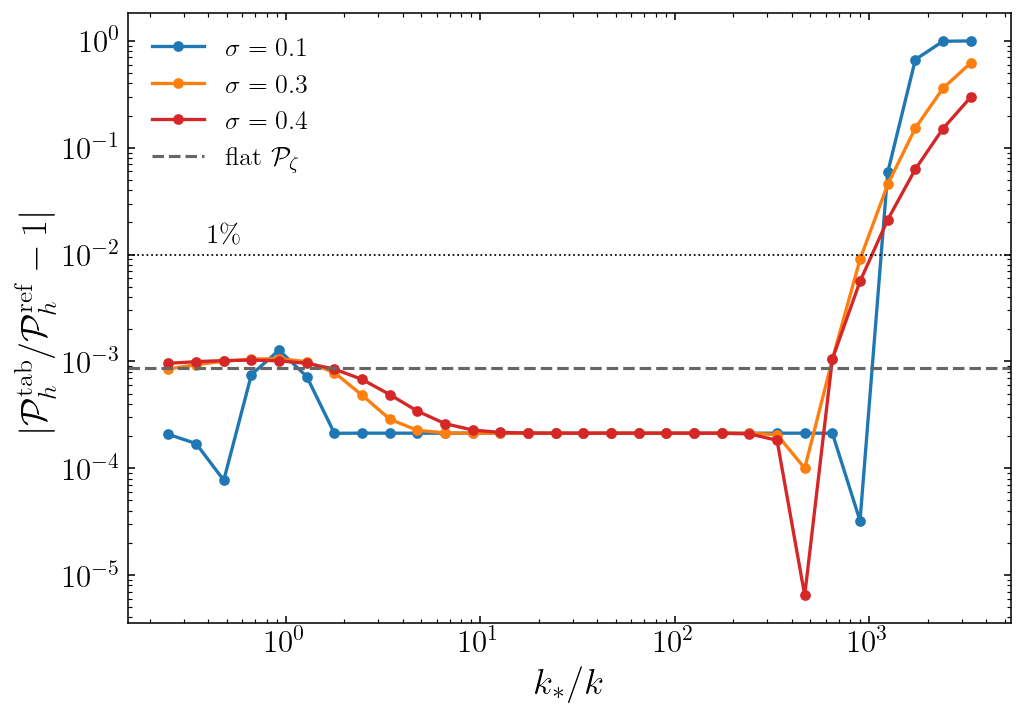

saved table_coverage.pdf


In [2]:
def Ph_on_table_grid(t_grid, s_grid, pz):
    T, S = np.meshgrid(t_grid, s_grid, indexing="ij")
    W = K.weight(T, S) * pz(K.u_of(T, S)) * pz(K.v_of(T, S))
    I2 = K.I2bar_rd_exact(T, S)
    return 4.0 * trapezoid(trapezoid(W * I2, x=s_grid, axis=1), x=t_grid)


idx = np.load(os.path.join(KDATA, "index.npz"))
t_grid = np.load(sorted(glob.glob(os.path.join(KDATA, "kernel_f*.npz")))[0])["t"]
s_grid = sp.s_grid(int(idx["n_s"]))

kappas = np.geomspace(3e-4, 4.0, 30)
fig, ax = plt.subplots(figsize=(7.6, 5.4))
for sigma, c in zip([0.1, 0.3, 0.4], ["C0", "C1", "C3"]):
    err = np.empty_like(kappas)
    for j, kap in enumerate(kappas):
        spec = ("lognormal", 1.0 / kap, sigma)
        pz = sp.make_pzeta(spec)
        ph_tab = Ph_on_table_grid(t_grid, s_grid, pz)
        ph_ref = sp.Ph(1.0, spec, i2bar=K.I2bar_rd_exact, n_s=201, n_seg=300)
        err[j] = abs(ph_tab / ph_ref - 1.0)
    ax.loglog(1.0 / kappas, np.clip(err, 1e-8, None), "o-", ms=4.5, lw=1.7,
              color=c, label=rf"$\sigma={sigma}$")
ph_tab = Ph_on_table_grid(t_grid, s_grid, lambda q: np.ones_like(q))
ph_ref = sp.Ph(1.0, ("flat",), i2bar=K.I2bar_rd_exact, n_s=201, n_seg=300, t_max_flat=30000.0)
ax.axhline(abs(ph_tab / ph_ref - 1.0), color="0.4", lw=1.6, ls="--", label=r"flat $\mathcal{P}_\zeta$")
ax.axhline(0.01, color="k", lw=0.9, ls=":")
ax.text(0.4, 0.013, r"$1\%$", fontsize=14)
ax.set_xlabel(r"$k_\ast/k$")
ax.set_ylabel(r"$|\mathcal{P}_h^{\rm tab}/\mathcal{P}_h^{\rm ref}-1|$")
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "table_coverage.pdf"))
plt.show()
print("saved table_coverage.pdf")

## Figure 4: flat (scale-invariant) spectrum

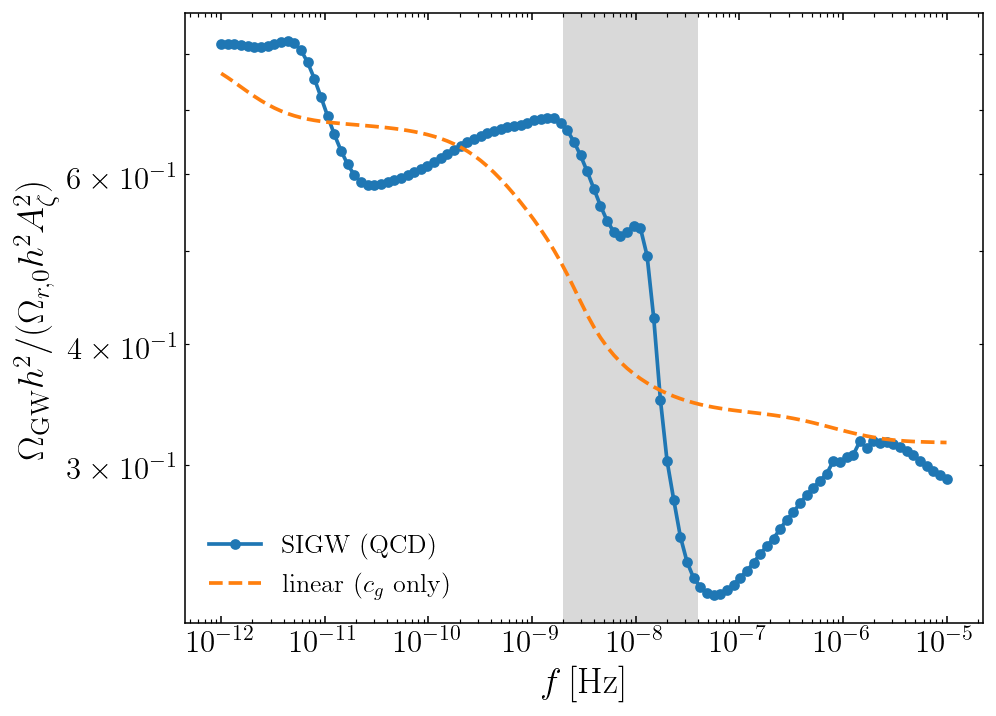

saved OGW_flat.pdf


In [3]:
Ph_tab = np.array([Ph_from_table(t, sp.flat, k) for t, k in zip(tabs, ks_nodes)])
om_tab = np.array([sp.omega_gw(float(k), p, qcd, ETA_F) for k, p in zip(ks_nodes, Ph_tab)])
d = np.load(os.path.join(DATA, "flat_spectrum.npz"))
Ph_rd = float(d["Ph_rd"])
om_lin = np.array([sp.omega_gw(float(k), Ph_rd, qcd, ETA_F, eta_c=1.0 / float(k))
                   for k in ks_nodes])

fig, ax = plt.subplots(figsize=(7.4, 5.4))
add_pta_band(ax, "f")
ax.loglog(f_nHz_nodes * NHZ_TO_HZ, om_tab, "o-", ms=4.5, lw=1.9, color="C0", label=r"SIGW (QCD)")
ax.loglog(f_nHz_nodes * NHZ_TO_HZ, om_lin, "--", lw=1.9, color="C1", label=r"linear ($c_g$ only)")
ax.set_xlabel(r"$f\,[\mathrm{Hz}]$")
ax.set_ylabel(r"$\Omega_{\rm GW}h^2/(\Omega_{r,0}h^2A_\zeta^2)$")
ax.legend(loc="lower left")
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "OGW_flat.pdf"))
plt.show()
print("saved OGW_flat.pdf")

## Figure 5: lognormal spectra (4 peak frequencies) and peak-height ratio

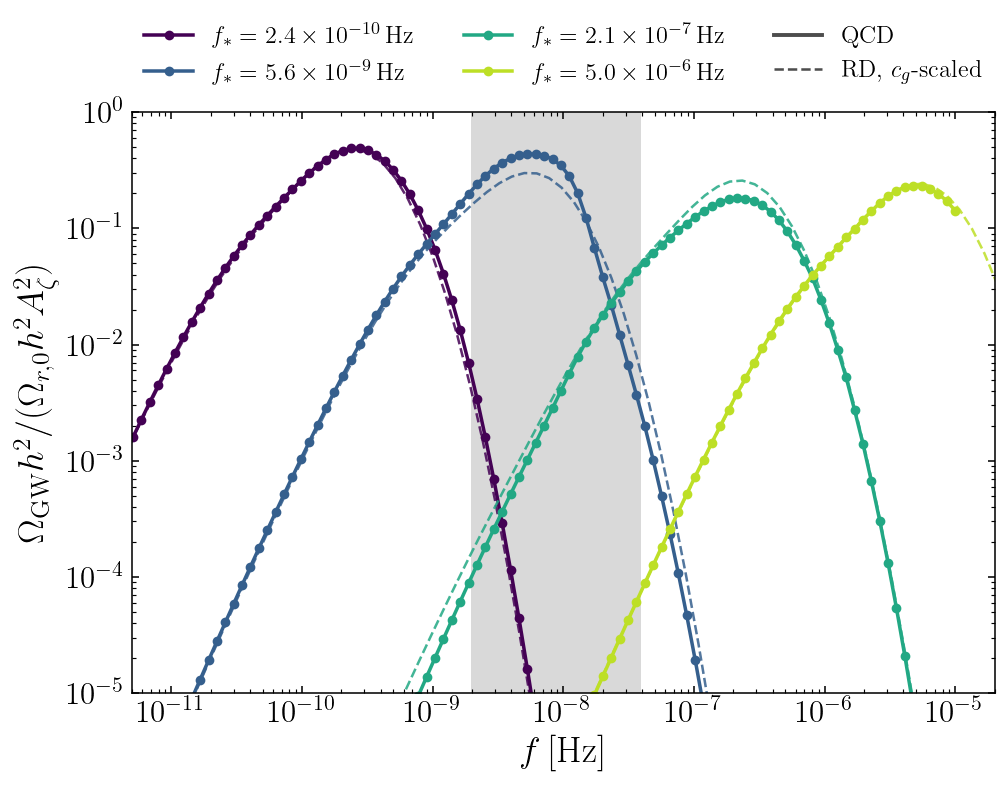

saved OGW_lognormal.pdf


In [4]:
SIGMA = 0.4
fstars_nHz = [0.24, 5.6, 210.0, 5000.0]
colors = cm.viridis(np.linspace(0.0, 0.9, len(fstars_nHz)))

fig, ax = plt.subplots(figsize=(7.6, 5.9))
add_pta_band(ax, "f")
for fstar_nHz, c in zip(fstars_nHz, colors):
    kstar = float(sp.f_Hz_to_k(np.array([fstar_nHz * 1e-9]))[0])
    spec = ("lognormal", kstar, SIGMA)
    pz = sp.make_pzeta(spec)
    Ph_qcd = np.array([Ph_from_table(t, pz, k) for t, k in zip(tabs, ks_nodes)])
    om_qcd = np.array([sp.omega_gw(float(k), p, qcd, ETA_F) for k, p in zip(ks_nodes, Ph_qcd)])
    f_rd = np.geomspace(max(fstar_nHz * 1e-3, 1e-4), fstar_nHz * 30.0, 48)
    ks_rd = sp.f_Hz_to_k(f_rd * 1e-9)
    Ph_rd = np.array([sp.Ph(float(k), spec, i2bar=K.I2bar_rd_exact, n_s=51, n_seg=100) for k in ks_rd])
    om_rd = np.array([sp.omega_gw(float(k), p, qcd, ETA_F, eta_c=1.0 / float(k)) for k, p in zip(ks_rd, Ph_rd)])
    fstar_Hz = fstar_nHz * 1e-9
    expo = int(np.floor(np.log10(fstar_Hz)))
    mant = fstar_Hz / 10.0**expo
    lab = rf"$f_\ast={mant:.1f}\times10^{{{expo}}}\,$Hz"
    ax.loglog(f_rd * NHZ_TO_HZ, om_rd, "--", lw=1.3, color=c, alpha=0.85)
    ax.loglog(f_nHz_nodes * NHZ_TO_HZ, om_qcd, "o-", ms=4, lw=1.8, color=c, label=lab)

ax.plot([], [], "-", lw=2.0, color="0.3", label=r"QCD")
ax.plot([], [], "--", lw=1.3, color="0.3", label=r"RD, $c_g$-scaled")
ax.set_ylim(1e-5, 1.0)
ax.set_xlim(5e-12, 2e-5)
ax.set_xlabel(r"$f\,[\mathrm{Hz}]$")
ax.set_ylabel(r"$\Omega_{\rm GW}h^2/(\Omega_{r,0}h^2A_\zeta^2)$")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=3, fontsize=12.5, frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "OGW_lognormal.pdf"))
plt.show()
print("saved OGW_lognormal.pdf")

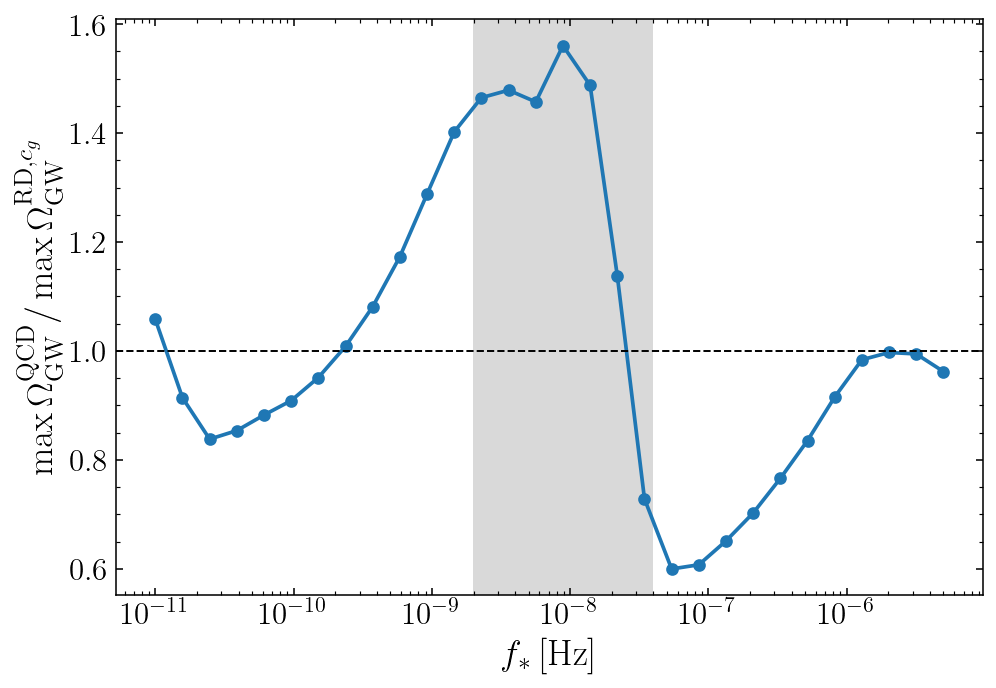

saved peak_ratio.pdf


In [5]:
fstars_nHz = np.geomspace(0.01, 5e3, 30)
peak_q = np.empty(len(fstars_nHz))
peak_r = np.empty(len(fstars_nHz))
for i, fstar_nHz in enumerate(fstars_nHz):
    kstar = float(sp.f_Hz_to_k(np.array([fstar_nHz * 1e-9]))[0])
    spec = ("lognormal", kstar, SIGMA)
    pz = sp.make_pzeta(spec)
    Ph_qcd = np.array([Ph_from_table(t, pz, k) for t, k in zip(tabs, ks_nodes)])
    om_qcd = np.array([sp.omega_gw(float(k), p, qcd, ETA_F) for k, p in zip(ks_nodes, Ph_qcd)])
    f_rd = np.geomspace(max(fstar_nHz * 1e-3, 1e-4), min(fstar_nHz * 3.0, 3e4), 40)
    ks_rd = sp.f_Hz_to_k(f_rd * 1e-9)
    Ph_rd = np.array([sp.Ph(float(k), spec, i2bar=K.I2bar_rd_exact, n_s=51, n_seg=100) for k in ks_rd])
    om_rd = np.array([sp.omega_gw(float(k), p, qcd, ETA_F, eta_c=1.0 / float(k)) for k, p in zip(ks_rd, Ph_rd)])
    peak_q[i], peak_r[i] = om_qcd.max(), om_rd.max()

fig, ax = plt.subplots(figsize=(7.4, 5.2))
add_pta_band(ax, "f")
ax.semilogx(fstars_nHz * NHZ_TO_HZ, peak_q / peak_r, "o-", ms=5.5, lw=1.9, color="C0")
ax.axhline(1.0, color="k", lw=1.0, ls="--")
ax.set_xlabel(r"$f_\ast\,[\mathrm{Hz}]$")
ax.set_ylabel(r"$\max\Omega_{\rm GW}^{\rm QCD}/\max\Omega_{\rm GW}^{{\rm RD},c_g}$")
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "peak_ratio.pdf"))
plt.show()
print("saved peak_ratio.pdf")